In [19]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Classes:
<StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str

Number of Classes:
4

Images Per Class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


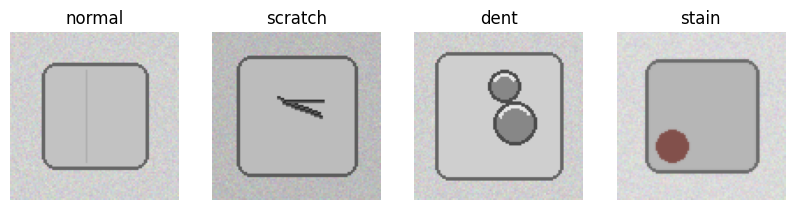


Sample Image Dimensions:
[(96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96), (96, 96)]

Class Distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Dataset is balanced

Training Images : 384
Testing Images  : 96

Augmented Images:
(10, 128, 128, 3)
CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=57600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


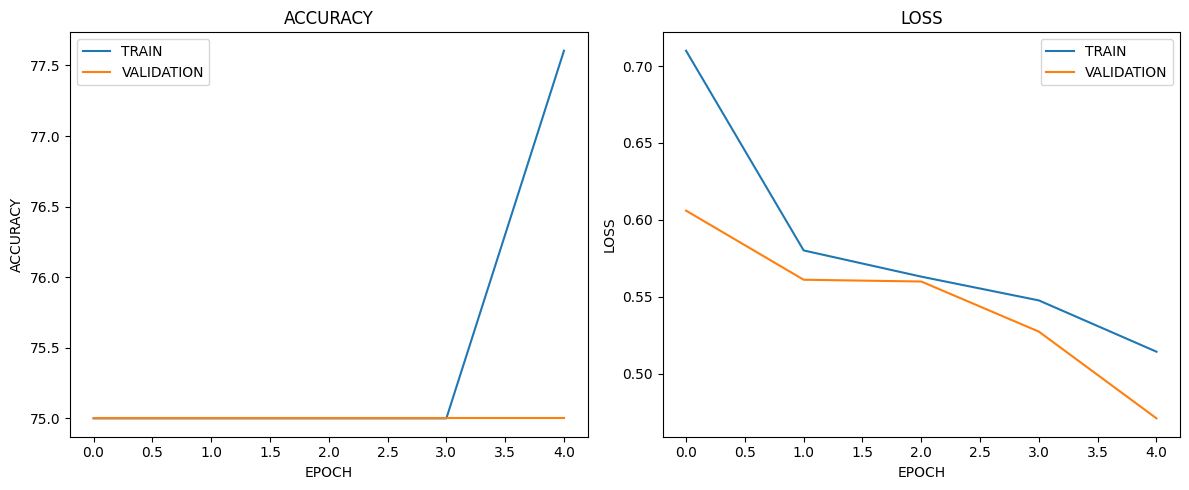

TEST ACCURACY :
75.0

CONFUSION MATRIX :
[[72  0]
 [24  0]]


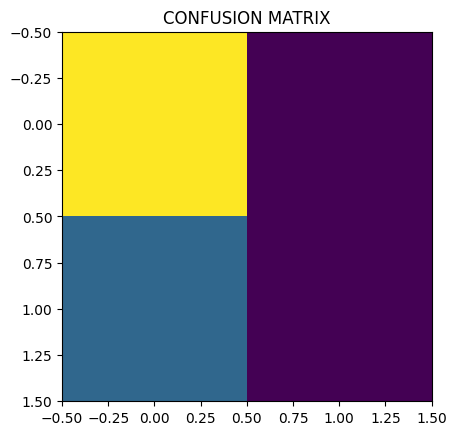

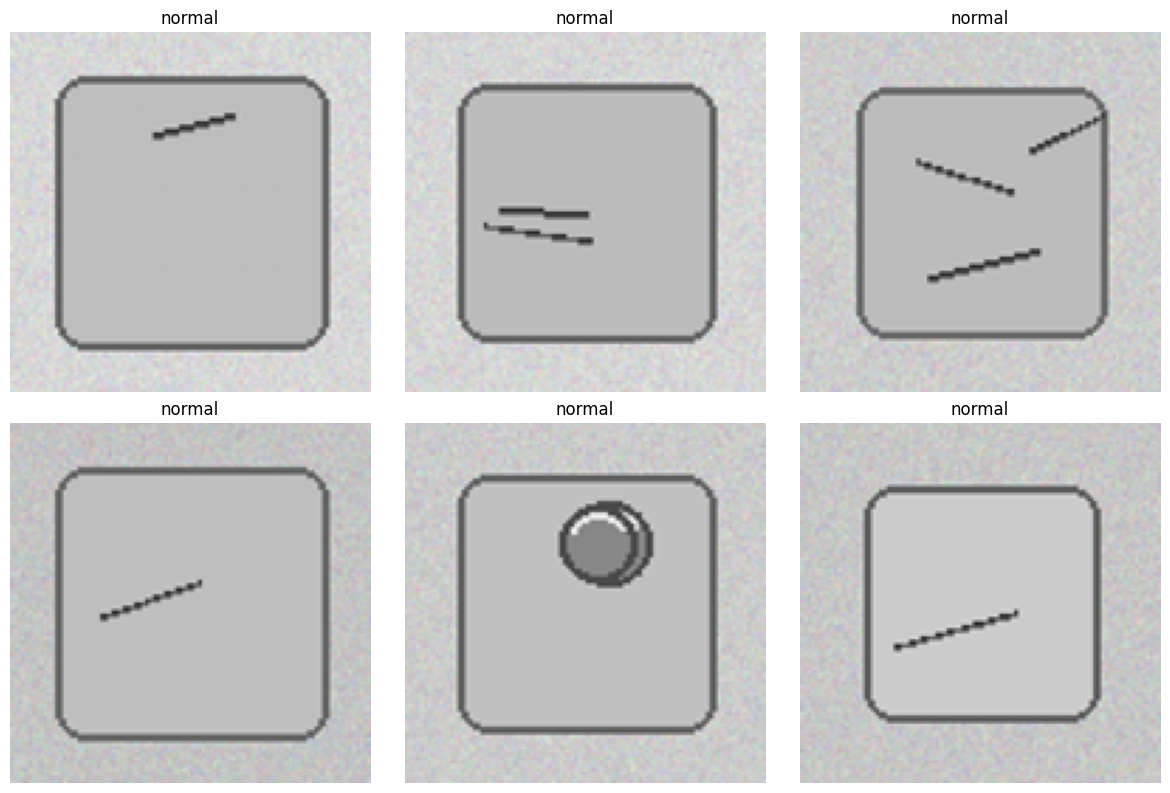

In [20]:
##=========TASK 2 = DATASET EXPLORATION============

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = "part_2_cnn_computer_vision"

labels_data = pd.read_csv(
    os.path.join(DATASET_PATH, "labels.csv")
)

## NUMBER OF CLASSES

all_classes = labels_data['class'].unique()

print("Classes:")
print(all_classes)

print("\nNumber of Classes:")
print(len(all_classes))

## NUMBER OF IMAGES PER CLASS

class_counts = labels_data['class'].value_counts()

print("\nImages Per Class:")
print(class_counts)

## SAMPLE IMAGES FROM EACH CLASS

fig, axes = plt.subplots(
    1,
    len(all_classes),
    figsize=(10, 5)
)

for idx, class_name in enumerate(all_classes):

    selected_row = labels_data[
        labels_data['class'] == class_name
    ].sample(1)

    file_name = selected_row['filename'].values[0]

    full_image_path = os.path.join(
        DATASET_PATH,
        file_name
    )

    image = Image.open(full_image_path)

    axes[idx].imshow(image)
    axes[idx].set_title(class_name)
    axes[idx].axis('off')

plt.show()


## IMAGE DIMENSIONS

image_sizes = []

for img_file in labels_data['filename']:

    current_image_path = os.path.join(
        DATASET_PATH,
        img_file
    )

    current_img = Image.open(current_image_path)

    width, height = current_img.size

    image_sizes.append((width, height))

print("\nSample Image Dimensions:")
print(image_sizes[:10])


## DATASET IMBALANCE CHECK IN THE DATASET

print("\nClass Distribution:")
print(class_counts)

max_count = class_counts.max()
min_count = class_counts.min()

difference = max_count - min_count

if difference > 20:
    print("\nDataset is imbalanced")
else:
    print("\nDataset is balanced")


##===========TASK 3 = IMAGE PREPROCESSING==========

from PIL import Image

from sklearn.model_selection import train_test_split

## RESIZING IMAGES TO A FIXED SIZE

IMG_HEIGHT = 128
IMG_WIDTH = 128

images = []
labels = []


for i,current_row in labels_data.iterrows():

    current_path = os.path.join(
        DATASET_PATH,
        current_row['filename']
    )

    image = Image.open(current_path)

    image = image.resize(
        (IMG_WIDTH, IMG_HEIGHT)
    )

    image_array = np.array(image)

    ## NORMALIZE PIXEL VALUES

    image_array = image_array / 255.0

    images.append(image_array)

    labels.append(current_row['class'])


X = np.array(images)
y = np.array(labels)


## SPLITTING INTO TRAINING AND TESTING SET


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("\nTraining Images :", X_train.shape[0])

print("Testing Images  :", X_test.shape[0])


## APPLYING AUGMENTATION

augmented_images = []

for sample_img in X_train[:10]:

    # horizontal flip
    flipped_image = np.fliplr(sample_img)

    augmented_images.append(flipped_image)

augmented_images = np.array(augmented_images)

print("\nAugmented Images:")
print(augmented_images.shape)


##===========TASK 4 = CNN MODEL CREATION===========

import torch
import torch.nn as nn


class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel, self).__init__()

        ## CONVOLUTION LAYER

        self.conv1 = nn.Conv2d(

            in_channels=3,

            out_channels=32,

            kernel_size=3
        )

        ## second conv layer
        self.conv2 = nn.Conv2d(

            in_channels=32,

            out_channels=64,

            kernel_size=3
        )

        ## ACTIVATION FUNCTION

        self.relu = nn.ReLU()

        ## POOLING LAYER

        self.pool = nn.MaxPool2d(

            kernel_size=2,

            stride=2
        )

        ## FLATTEN LAYER

        self.flatten = nn.Flatten()

        ## DENSE LAYER

        self.fc1 = nn.Linear(

            64 * 30 * 30,

            128
        )

        ## OUTPUT LAYER

        self.fc2 = nn.Linear(

            128,

            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        x = self.sigmoid(x)

        return x


model = CNNModel()

print(model)

##==============TASK 5 = MODEL TRAINING AND EVALUATION===============

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

## TRAINING ACCURACY/LOSS
## VALIDATION ACCURACY/LOSS

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
).permute(0, 3, 1, 2)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
).permute(0, 3, 1, 2)

y_train_values = np.where(
    y_train == 'dent',
    1,
    0
)

y_test_values = np.where(
    y_test == 'dent',
    1,
    0
)

y_train_tensor = torch.tensor(
    y_train_values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test_values,
    dtype=torch.float32
).view(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

train_accuracy = []

train_loss = []

validation_accuracy = []

validation_loss = []

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    correct_predictions = 0

    total_images = 0

    for batch_images, batch_labels in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_images)

        loss = criterion(
            outputs,
            batch_labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predicted = (
            outputs > 0.5
        ).float()

        total_images += batch_labels.size(0)

        correct_predictions += (
            predicted == batch_labels
        ).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = (
        100 * correct_predictions / total_images
    )

    train_loss.append(epoch_loss)
    train_accuracy.append(epoch_accuracy)
    model.eval()

    validation_running_loss = 0
    validation_correct = 0
    validation_total = 0

    with torch.no_grad():

        for val_images, val_labels in test_loader:

            outputs = model(val_images)

            loss = criterion(
                outputs,
                val_labels
            )

            validation_running_loss += loss.item()

            predicted = (
                outputs > 0.5
            ).float()

            validation_total += val_labels.size(0)

            validation_correct += (
                predicted == val_labels
            ).sum().item()

    validation_epoch_loss = (
        validation_running_loss / len(test_loader)
    )

    validation_epoch_accuracy = (
        100 * validation_correct / validation_total
    )

    validation_loss.append(
        validation_epoch_loss
    )

    validation_accuracy.append(
        validation_epoch_accuracy
    )


## ACCURACY LOSS CURVES

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy)
plt.plot(validation_accuracy)
plt.title("ACCURACY")
plt.xlabel("EPOCH")
plt.ylabel("ACCURACY")

plt.legend([
    "TRAIN",
    "VALIDATION"
])

plt.subplot(1, 2, 2)
plt.plot(train_loss)
plt.plot(validation_loss)
plt.title("LOSS")
plt.xlabel("EPOCH")
plt.ylabel("LOSS")

plt.legend([
    "TRAIN",
    "VALIDATION"
])

plt.tight_layout()

plt.savefig(
    "accuracy_loss_curves.png"
)

plt.show()


## TESTING PERFORMANCE

model.eval()

correct = 0
total = 0

all_predictions = []

all_labels = []

with torch.no_grad():

    for test_images, test_labels in test_loader:

        outputs = model(test_images)

        predicted = (
            outputs > 0.5
        ).float()

        total += test_labels.size(0)

        correct += (
            predicted == test_labels
        ).sum().item()

        all_predictions.extend(
            predicted.numpy()
        )

        all_labels.extend(
            test_labels.numpy()
        )

test_accuracy = 100 * correct / total

print("TEST ACCURACY :")

print(test_accuracy)

## CONFUSION MATRIX

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nCONFUSION MATRIX :")

print(cm)

plt.imshow(cm)
plt.title("CONFUSION MATRIX")

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

## SAMPLE PREDICTIONS ON TEST IMAGES

test_samples = X_test_tensor[:6]

with torch.no_grad():

    sample_predictions = model(test_samples)

sample_predictions = (
    sample_predictions > 0.5
).float()

plt.figure(figsize=(12, 8))

for index in range(6):

    plt.subplot(2, 3, index + 1)

    current_image = test_samples[index].permute(
        1,
        2,
        0
    ).numpy()

    plt.imshow(current_image)

    predicted_output = (
        "dent"
        if sample_predictions[index] == 1
        else "normal"
    )

    plt.title(predicted_output)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "prediction_outputs.png"
)

plt.show()